# Лабораторная работа №3

**Вариант 17**


In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from numpy.lib.stride_tricks import sliding_window_view

plt.rcParams["figure.dpi"] = 120

VARIANT = 17
SELECTED_NAMES = ["01.png", "02.png"]

lab3_candidates = [
    Path.cwd(),
    Path.cwd() / "lab3_project",
]

LAB3_BASE = next(
    (path for path in lab3_candidates if (path / "results").exists() and (path / "task").exists()),
    lab3_candidates[0],
)

source_candidates = [
    LAB3_BASE.parent / "lab2" / "lab2_variant17" / "source_png",
    Path.cwd() / "lab2" / "lab2_variant17" / "source_png",
]

SOURCE_DIR = next((path for path in source_candidates if path.exists()), source_candidates[0])
RESULTS_DIR = LAB3_BASE / "results" / f"variant_{VARIANT:02d}"
FILTERED_DIR = RESULTS_DIR / "filtered"
DIFF_DIR = RESULTS_DIR / "difference"

FILTERED_DIR.mkdir(parents=True, exist_ok=True)
DIFF_DIR.mkdir(parents=True, exist_ok=True)

for folder in [FILTERED_DIR, DIFF_DIR]:
    for old_file in folder.glob("*.png"):
        old_file.unlink()

image_paths = [SOURCE_DIR / name for name in SELECTED_NAMES]
missing = [path.name for path in image_paths if not path.exists()]
if missing:
    raise FileNotFoundError(f"Не найдены исходные файлы: {missing}")


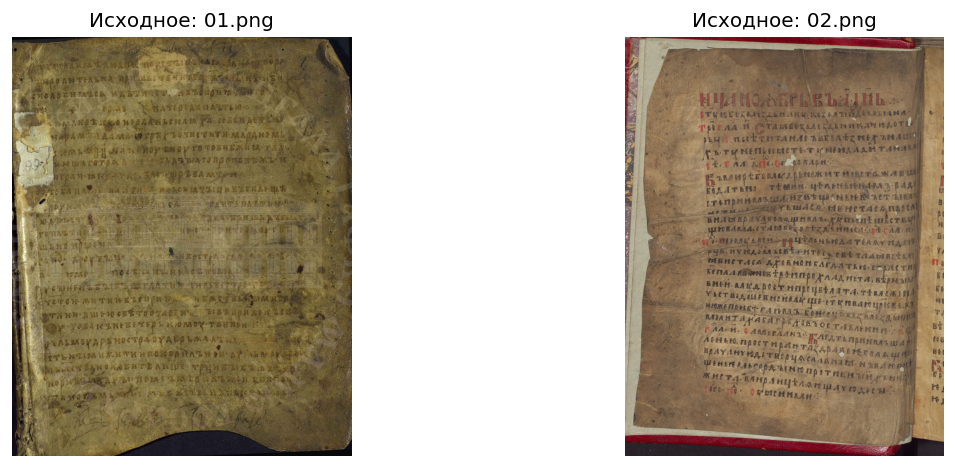

In [2]:
fig, axes = plt.subplots(1, len(image_paths), figsize=(6 * len(image_paths), 4))
if len(image_paths) == 1:
    axes = [axes]

for ax, path in zip(axes, image_paths):
    image = np.array(Image.open(path).convert("RGB"))
    ax.imshow(image)
    ax.set_title(f"Исходное: {path.name}")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [3]:
def rgb_to_gray(rgb):
    rgb = rgb.astype(np.float32)
    gray = 0.299 * rgb[..., 0] + 0.587 * rgb[..., 1] + 0.114 * rgb[..., 2]
    return np.clip(np.round(gray), 0, 255).astype(np.uint8)


def otsu_threshold(gray):
    hist = np.bincount(gray.ravel(), minlength=256).astype(np.float64)
    prob = hist / hist.sum()
    omega = np.cumsum(prob)
    mu = np.cumsum(prob * np.arange(256))
    mu_total = mu[-1]
    sigma = (mu_total * omega - mu) ** 2 / (omega * (1.0 - omega) + 1e-12)
    return int(np.argmax(sigma))


def to_binary(gray):
    threshold = otsu_threshold(gray)
    return np.where(gray <= threshold, 0, 255).astype(np.uint8)


def erode_square(binary, size=3):
    if size % 2 == 0:
        raise ValueError("Размер структурирующего элемента должен быть нечётным")

    pad = size // 2
    foreground = binary == 0
    padded = np.pad(foreground, pad, mode="constant", constant_values=False)
    windows = sliding_window_view(padded, (size, size))
    eroded = windows.all(axis=(-2, -1))
    return np.where(eroded, 0, 255).astype(np.uint8)


def xor_difference(src, dst):
    return np.where(src != dst, 255, 0).astype(np.uint8)


def save_gray(path, array):
    Image.fromarray(array, mode="L").save(path)


In [4]:
processed = []

for path in image_paths:
    rgb = np.array(Image.open(path).convert("RGB"))
    gray = rgb_to_gray(rgb)
    src = to_binary(gray)
    dst = erode_square(src, size=3)
    diff = xor_difference(src, dst)

    save_gray(FILTERED_DIR / path.name, dst)
    save_gray(DIFF_DIR / path.name, diff)
    processed.append((path, src, dst, diff))

print(f"Готово: {len(processed)} файла")


Готово: 2 файла


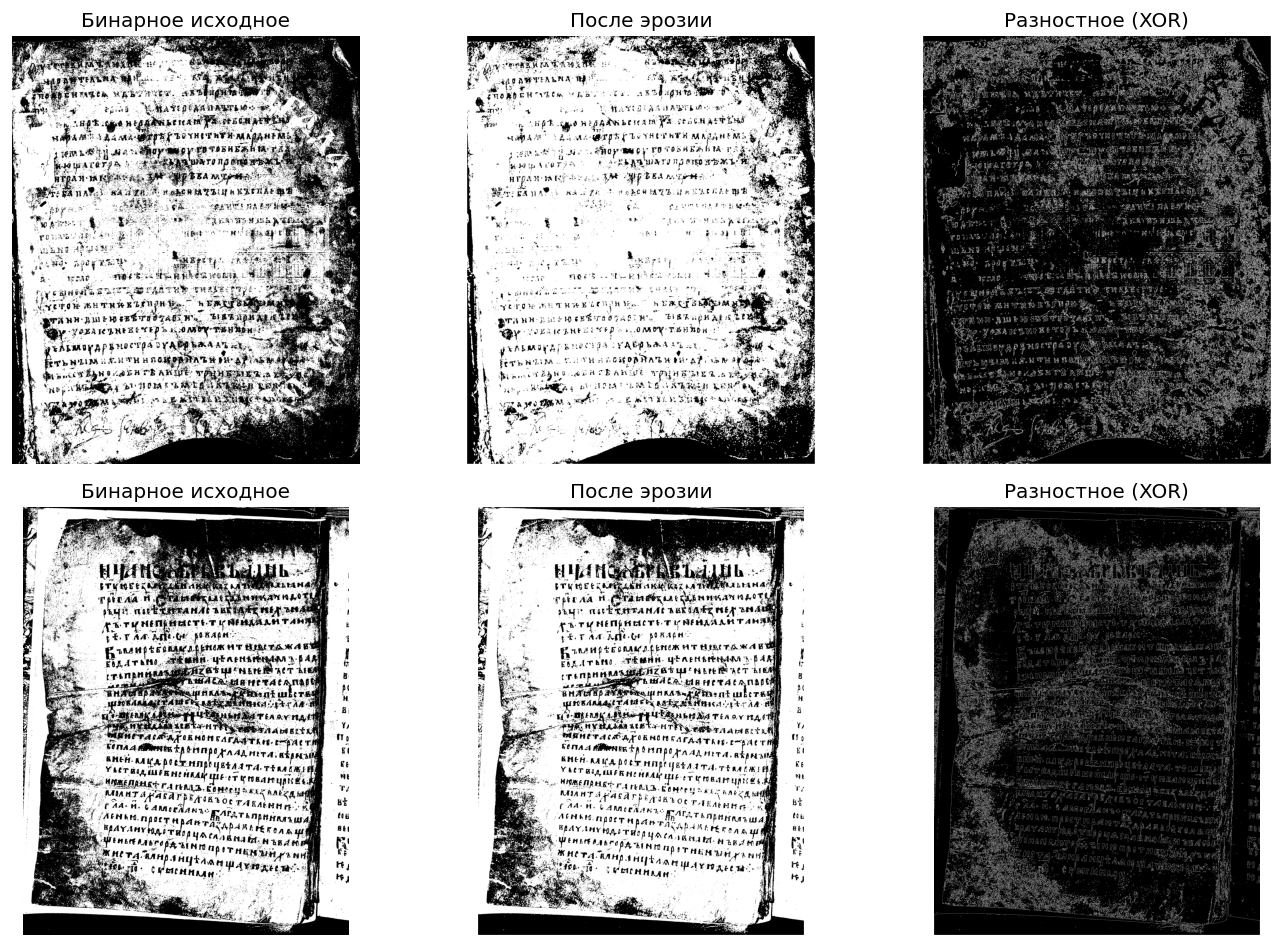

In [5]:
n = len(processed)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = np.array([axes])

for i in range(n):
    _, src, dst, diff = processed[i]
    axes[i, 0].imshow(src, cmap="gray", vmin=0, vmax=255)
    axes[i, 0].set_title("Бинарное исходное")
    axes[i, 1].imshow(dst, cmap="gray", vmin=0, vmax=255)
    axes[i, 1].set_title("После эрозии")
    axes[i, 2].imshow(diff, cmap="gray", vmin=0, vmax=255)
    axes[i, 2].set_title("Разностное (XOR)")
    for j in range(3):
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()
